In [221]:
import sys
import importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")

import src.dataset
# importlib.reload(src.dataset)

batch = next(iter(src.dataset.train_dataloader))
print(f"Shape of one image: {batch[0][0].shape}")
print(f"A single label: {batch[1][0]} | Corresponding lbl-idx:", end=" ")

idx_to_class = {v:k for k,v in src.dataset.plant_dataset.class_to_idx.items()}
print(idx_to_class[batch[1][0].item()])

Shape of one image: torch.Size([3, 224, 224])
A single label: 8 | Corresponding lbl-idx: Tomato_Leaf_Mold


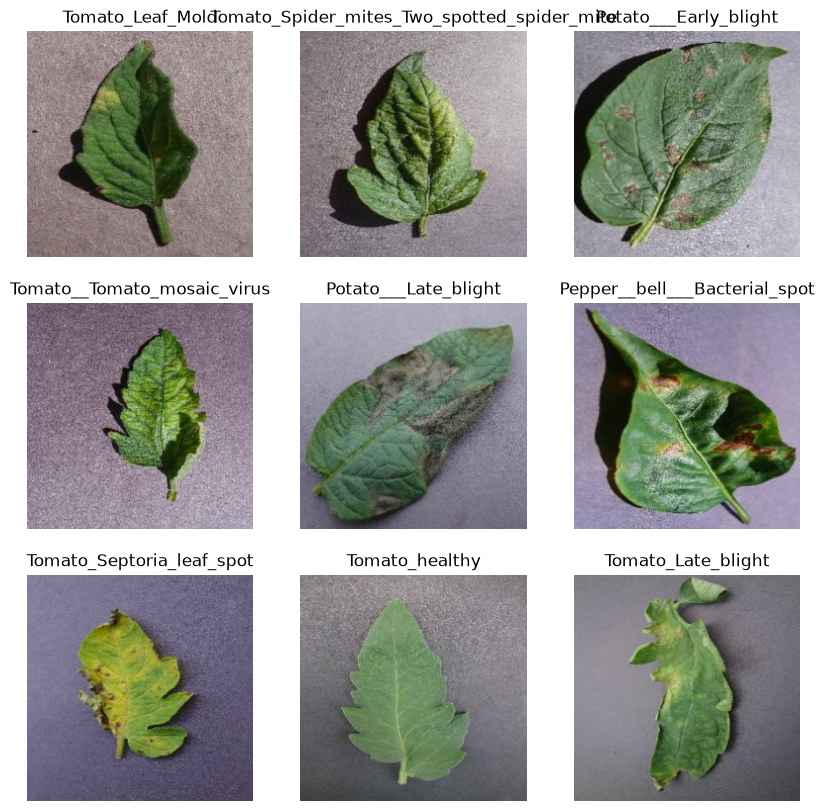

In [ ]:
def show_image(img_tensor, label_idx, ax):
    mean = torch.Tensor(src.dataset.MEAN_VALUE)
    mean = mean.reshape(3, 1, 1)

    std = torch.Tensor(src.dataset.STD_VALUE)
    std = std.reshape(3, 1, 1)

    unnormalized = img_tensor * std + mean
    permuted = unnormalized.permute(1,2,0)
    numpy_img = permuted.numpy()
    clipped = np.clip(numpy_img, 0, 1)
    
    ax.imshow(clipped)
    ax.axis("off")
    ax.set_title(idx_to_class[label_idx])

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes_flat = axes.flatten()

for i in range(0, 9):
    show_image(batch[0][i], batch[1][i].item(), axes_flat[i])

plt.tight_layout()
plt.axis("off")
plt.show()